# EVT — GPD Fit to Parkrun Personal Bests

Fit a Generalised Pareto Distribution to the left tail of personal best finish times for every (Event Name, Gender) pair and estimate the theoretical fastest-possible time with a 95 % bootstrap confidence interval.

**Method**
1. Deduplicate to one personal-best per (Runner_ID, Event Name).
2. For each (Event Name, Gender) group set threshold *u* = 10th-percentile of `mins`.  
   Exceedances: $z_i = u - x_i > 0$ for all $x_i < u$.  
   Discard groups with fewer than 30 tail observations.
3. Fit GPD via MLE: `scipy.stats.genpareto.fit(z, floc=0)` → $(c, 0, \sigma)$ with $c = \xi$.
4. If $\xi < 0$ the tail is bounded; the hard lower bound is $\hat{\mu}^* = u - \sigma / |\xi|$.  
   If $\xi \geq 0$ the course is flagged as *unbounded_tail* and excluded.
5. 95 % CI from 1 000 bootstrap resamples of the tail.

In [1]:
from parkrun.data import load_clean_data


In [2]:
df = load_clean_data()


In [3]:
df.columns

Index(['Event Name', 'Event Date', 'Event Number', 'Position', 'Name',
       'Gender', 'Gender Position', 'Gender Total', 'Age Group', 'Age Grade %',
       'Time', 'Time Details', 'Achievement', 'Total parkruns',
       'Volunteer Count', 'Club Membership', 'Volunteer Club', 'Club', 'mins',
       'Runner_ID'],
      dtype='str')

In [17]:
import numpy as np
import pandas as pd
from scipy.stats import genpareto
from parkrun.utils import format_time

## Step 1 — Deduplicate to personal bests

In [18]:
# One personal-best row per (Runner_ID, Event Name): keep the minimum 'mins' run.
pb = (
    df.loc[df.groupby(["Runner_ID", "Event Name"])["mins"].idxmin()]
    .copy()
    .reset_index(drop=True)
)
print(f"Full data : {len(df):>10,} rows")
print(
    f"Pers. bests: {len(pb):>10,} rows  ({pb['Runner_ID'].nunique():,} unique runners)"
)

Full data :  9,035,426 rows
Pers. bests:  3,130,844 rows  (1,295,973 unique runners)


## Steps 2–6 — GPD fitting function

In [28]:
TAIL_PERCENTILE = 10  # retain fastest 10 % as the tail
MIN_TAIL_SIZE = 60  # discard groups smaller than this
N_BOOTSTRAP = 100
RNG = np.random.default_rng(42)


def fit_gpd_tail(mins_array: np.ndarray) -> dict:
    """Fit a GPD to the left tail of *mins_array* (personal-best times in minutes).

    Returns a dict with keys:
        status              : 'ok' | 'too_few_tail' | 'unbounded_tail'
        n_unique_runners    : total runners in group
        n_tail_sample       : size of exceedance sample (when attempted)
        threshold_u         : 10th-percentile threshold (when computed)
        xi_hat, sigma_hat   : MLE estimates (when status == 'ok')
        estimated_limit_mins: hard lower bound (when status == 'ok')
        ci_lower_mins       : bootstrap 2.5th percentile
        ci_upper_mins       : bootstrap 97.5th percentile
    """
    x = np.asarray(mins_array, dtype=float)
    n = len(x)
    base = {"n_unique_runners": n}

    u = np.percentile(x, TAIL_PERCENTILE)
    z = u - x[x < u]  # exceedances z_i = u - x_i > 0

    base["n_tail_sample"] = len(z)
    base["threshold_u"] = u

    if len(z) < MIN_TAIL_SIZE:
        return {**base, "status": "too_few_tail"}

    c, _loc, sigma = genpareto.fit(z, floc=0)
    base["xi_hat"] = c
    base["sigma_hat"] = sigma

    if c >= 0:
        return {**base, "status": "unbounded_tail"}

    mu_star = u - sigma / abs(c)

    # Bootstrap CI — resample exceedances with replacement, refit, recompute bound
    boot_limits = []
    for _ in range(N_BOOTSTRAP):
        z_boot = RNG.choice(z, size=len(z), replace=True)
        bc, _, bsig = genpareto.fit(z_boot, floc=0)
        if bc < 0:
            boot_limits.append(u - bsig / abs(bc))

    boot_limits = np.array(boot_limits)
    ci_lower = float(np.percentile(boot_limits, 2.5)) if len(boot_limits) else np.nan
    ci_upper = float(np.percentile(boot_limits, 97.5)) if len(boot_limits) else np.nan

    return {
        **base,
        "status": "ok",
        "estimated_limit_mins": float(mu_star),
        "ci_lower_mins": ci_lower,
        "ci_upper_mins": ci_upper,
    }

## Fit across all (Event Name, Gender) groups

In [30]:
import warnings
from tqdm import tqdm

records = []
groups = pb.groupby(["Event Name", "Gender"], sort=True)
total = len(groups)

for i, ((event, gender), grp) in tqdm(enumerate(groups, 1), total=total):
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")  # suppress scipy convergence warnings
        res = fit_gpd_tail(grp["mins"].values)

    records.append({"Event Name": event, "Gender": gender, **res})
    if i > 100:
        break

print(f"\nDone — {total} (Event, Gender) pairs processed.")

raw = pd.DataFrame(records)
status_counts = raw["status"].value_counts()
print(status_counts.to_string())

  6%|▌         | 100/1638 [00:37<09:42,  2.64it/s]


Done — 1638 (Event, Gender) pairs processed.
status
ok              91
too_few_tail    10


## Step 7 — Output table

In [31]:
col_order = [
    "Event Name",
    "Gender",
    "n_unique_runners",
    "n_tail_sample",
    "threshold_u",
    "xi_hat",
    "sigma_hat",
    "estimated_limit_mins",
    "ci_lower_mins",
    "ci_upper_mins",
]

# Keep only successfully fitted rows
results = (
    raw[raw["status"] == "ok"]
    .reindex(columns=col_order)
    .sort_values(["Gender", "estimated_limit_mins"])
    .reset_index(drop=True)
)

# Human-readable MM:SS columns alongside the raw floats
for col in ("estimated_limit_mins", "ci_lower_mins", "ci_upper_mins"):
    str_col = col.replace("_mins", "_str")
    results[str_col] = results[col].apply(
        lambda v: format_time(v) if pd.notna(v) else ""
    )

print(f"Courses with a bounded-tail GPD fit: {len(results)}")
results

Courses with a bounded-tail GPD fit: 91


,Event Name,Gender,n_unique_runners,n_tail_sample,threshold_u,xi_hat,sigma_hat,estimated_limit_mins,ci_lower_mins,ci_upper_mins,estimated_limit_str,ci_lower_str,ci_upper_str
0,Battlestead Croft parkrun,Female,653,66,25.740000,-0.153582,2.097010,12.085999,-83.082949,19.925760,12:05,-84:55,19:56
1,Barking parkrun,Female,1113,111,24.516667,-0.229454,2.394781,14.079816,-91.816607,17.913103,14:05,-92:11,17:55
2,Babbs Mill parkrun,Female,1390,138,25.833333,-0.187863,2.044778,14.948911,5.337712,18.911489,14:57,5:20,18:55
3,Battersea parkrun,Female,10796,1076,22.700000,-0.387231,2.771093,15.543821,15.298674,16.199081,15:33,15:18,16:12
4,Alvaston parkrun,Female,2325,233,24.340000,-0.320134,2.797879,15.600278,12.743617,17.479556,15:36,12:45,17:29
...,...,...,...,...,...,...,...,...,...,...,...,...,...
86,Banbury parkrun,Male,2014,200,21.183333,-0.487278,2.082613,16.909364,16.648925,17.488605,16:55,16:39,17:29
87,Ancholme Valley Way parkrun,Male,944,95,20.338333,-0.591988,2.017993,16.929493,16.682845,17.302637,16:56,16:41,17:18
88,Babbs Mill parkrun,Male,1659,166,21.396667,-0.547254,2.435975,16.945394,16.605328,17.227790,16:57,16:36,17:14
89,Basildon parkrun,Male,1457,144,21.550000,-0.525708,2.323909,17.129466,16.490327,17.489387,17:08,16:29,17:29


In [ ]:
# Quick look: 15 theoretically fastest courses per gender
display_cols = [
    "Event Name",
    "n_unique_runners",
    "n_tail_sample",
    "xi_hat",
    "estimated_limit_str",
    "ci_lower_str",
    "ci_upper_str",
]
for gender in ("Male", "Female"):
    subset = results[results["Gender"] == gender].head(15)[display_cols]
    print(f"\n── {gender} — 15 fastest theoretical limits ──")
    print(subset.to_string(index=False))


── Male — 15 fastest theoretical limits ──
                         Event Name  n_unique_runners  n_tail_sample    xi_hat estimated_limit_str ci_lower_str ci_upper_str
               Arrow Valley parkrun              3356            336 -0.262411               13:31        12:14        16:00
                 Alice Holt parkrun              2728            273 -0.226016               13:34        10:54        16:25
                    Barking parkrun              1564            157 -0.297558               13:48        11:45        14:54
       Alexandra parkrun, Moss Side              5255            523 -0.327013               14:01        13:38        15:05
                     Antrim parkrun              1668            166 -0.274896               14:22        12:22        16:09
             Alderford Lake parkrun              1470            147 -0.246830               14:24        10:58        17:44
                  Battersea parkrun             13030           1302 -0.447630   

In [45]:
help(plt.errorbar)

Help on function errorbar in module matplotlib.pyplot:

errorbar(x: 'float | ArrayLike', y: 'float | ArrayLike', yerr: 'float | ArrayLike | None' = None, xerr: 'float | ArrayLike | None' = None, fmt: 'str' = '', *, ecolor: 'ColorType | None' = None, elinewidth: 'float | None' = None, capsize: 'float | None' = None, barsabove: 'bool' = False, lolims: 'bool | ArrayLike' = False, uplims: 'bool | ArrayLike' = False, xlolims: 'bool | ArrayLike' = False, xuplims: 'bool | ArrayLike' = False, errorevery: 'int | tuple[int, int]' = 1, capthick: 'float | None' = None, data=None, **kwargs) -> 'ErrorbarContainer'
    Plot y versus x as lines and/or markers with attached errorbars.

    *x*, *y* define the data locations, *xerr*, *yerr* define the errorbar
    sizes. By default, this draws the data markers/lines as well as the
    errorbars. Use fmt='none' to draw errorbars without any data markers.

    .. versionadded:: 3.7
       Caps and error lines are drawn in polar coordinates on polar plots.

<ErrorbarContainer object of 3 artists>

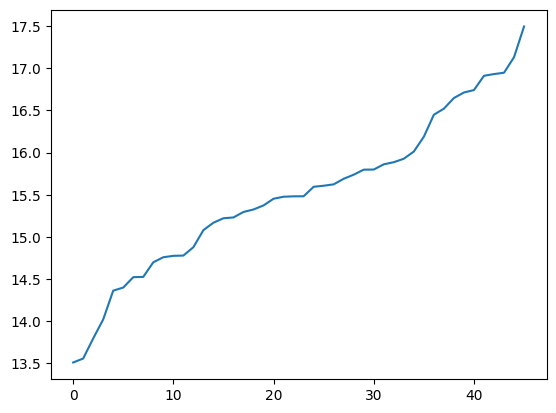

In [50]:
import matplotlib.pyplot as plt

plot_df = results[results["Gender"] == "Male"].sort_values("estimated_limit_mins")
plt.errorbar(
    x=np.arange(len(plot_df)),
    y=plot_df.estimated_limit_mins,
    lolims=plot_df.ci_lower_mins,
    uplims=plot_df.ci_upper_mins,
)